# 复现（data-预测2014-2023 ）

## 理论 from https://www.cnblogs.com/xuruilong100/p/9127151.html

一、整体步骤

1. **环境准备**：加载Python相关库（pandas, numpy, matplotlib, tensorflow/keras, scikit-learn等）。
2. **数据获取与预处理**：加载太阳黑子月度数据，转换为时间序列格式。
3. **探索性数据分析（EDA）**：
   - 可视化全量数据及局部周期。
   - 计算自相关函数（ACF），确定是否存在长期自相关性。
4. **时间序列交叉验证（回测策略）**：
   - 使用滚动窗口方式划分多个训练/测试集（例如：50年训练，10年测试，每次滑动20年）。
5. **构建状态化LSTM模型**：
   - 数据标准化（平方根变换 + 中心化 + 缩放）。
   - 将数据转换为3D张量（样本数，时间步长，特征数）。
   - 搭建多层LSTM（stateful=True）。
   - 编译模型（MAE损失，Adam优化器）。
6. **模型训练**：
   - 逐epoch手动重置状态，保持序列依赖。
7. **模型评估**：
   - 计算RMSE。
   - 可视化预测值与真实值对比。
8. **未来预测**：用全部历史数据预测未来10年。
9. **回测所有切片**：对每个时间窗口重复训练与评估，得到稳健的误差估计。


二、所用方法

- **状态化LSTM**：一种循环神经网络变体，可以在批次间保持隐藏状态，适合学习长期时间依赖。
- **时间序列交叉验证（Rolling Origin）**：模拟真实回测场景，避免未来信息泄露。
- **自相关函数（ACF）**：判断序列是否具有长记忆性，从而决定是否适合LSTM。
- **数据预处理**：平方根变换（稳定方差）、中心化与标准化（加速收敛）。
- **批量预测**：用固定长度的历史窗口一次性预测未来10年，而非单步迭代。

三、核心逻辑

1. **为什么用LSTM？**  
   太阳黑子数据具有约11年的周期，且ACF显示滞后120个月（10年）后相关系数仍>0.5，说明长期依赖存在，LSTM擅长捕捉这种模式。

2. **为什么是状态化？**  
   普通（无状态）LSTM会在每个批次后重置隐藏状态，丢失跨批次的时间连续性。状态化LSTM在批次间保持状态，使得模型能学习超过一个批次长度的依赖关系。

3. **为什么用滚动窗口回测？**  
   时间序列不能随机打乱。通过固定窗口平移，可以检验模型在不同历史时期（不同周期形态）上的泛化能力。

4. **为什么用平方根变换？**  
   太阳黑子计数具有方差不稳定的特点（振幅随时间变化），平方根变换能稳定方差，使数据更接近高斯分布，利于LSTM训练。


四、物理/数学内容

物理背景
- **太阳黑子**：太阳表面磁场活动导致的暗斑，数量变化周期约11年（施瓦贝周期）。
- 预测太阳黑子对空间天气、卫星通信、电力系统有实际意义。

数学内容
1. **LSTM单元数学**  
   每个单元包含输入门、遗忘门、输出门和细胞状态，公式如下（符号略简）：
   - $ f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) $  
   - $ i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) $  
   - $ \tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) $  
   - $ C_t = f_t * C_{t-1} + i_t * \tilde{C}_t $  
   - $ o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) $  
   - $ h_t = o_t * \tanh(C_t) $  
   门结构使梯度能长时间流动，缓解梯度消失。

2. **自相关函数（ACF）**  
   \[
   \rho_k = \frac{\sum_{t=1}^{n-k}(y_t - \bar{y})(y_{t+k} - \bar{y})}{\sum_{t=1}^{n}(y_t - \bar{y})^2}
   \]  
   衡量序列与其自身滞后k期的线性相关性。

3. **数据预处理数学**  
   - 平方根：$ x' = \sqrt{x} $ 
   - 中心化：$ x'' = x' - \mu $
   - 标准化：$ x''' = x'' / \sigma $

4. **损失函数**  
   MAE（平均绝对误差）：$$ \text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i| $$

5. **评估指标**  
   RMSE（均方根误差）：$$ \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2} $$

## coding

### may a failed test with a fine RMSSE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ============================
# 1. 加载月度太阳黑子数据
# ============================
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
data = pd.read_csv(url, header=0, names=['DATE', 'value'], parse_dates=['DATE'])
data.set_index('DATE', inplace=True)
print(f"总月度数据点数: {len(data)}")
print(data.head())
print(data.tail())

# ============================
# 2. ACF 自相关分析 (滞后最大 600 个月，即 50 年)
# ============================
plt.figure(figsize=(12, 6))
plot_acf(data['value'], lags=600, alpha=0.05)
plt.title('Sunspots Monthly Data - Autocorrelation Function')
plt.xlabel('Lag (months)')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()

#### epochs = 50  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ------------------------------
# 1. 加载月度太阳黑子数据
# ------------------------------
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
data = pd.read_csv(url, header=0, names=['DATE', 'value'], parse_dates=['DATE'])
data.set_index('DATE', inplace=True)
print(f"总月度数据点数: {len(data)}")
print(data.head())

# ------------------------------
# 2. 自定义 SqrtScaler（平方根变换 + 标准化）
# ------------------------------
class SqrtScaler:
    def fit(self, X):
        # X: shape (n_samples, 1)
        X_sqrt = np.sqrt(X)
        self.mean_ = np.mean(X_sqrt, axis=0)
        self.std_ = np.std(X_sqrt, axis=0)
        return self
    def transform(self, X):
        X_sqrt = np.sqrt(X)
        return (X_sqrt - self.mean_) / self.std_
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    def inverse_transform(self, X_scaled):
        X_sqrt = X_scaled * self.std_ + self.mean_
        return X_sqrt ** 2

# ------------------------------
# 3. 构建状态 LSTM 模型（stateful=True）
# ------------------------------
def build_stateful_lstm(batch_size, timesteps=1, units=50):
    model = Sequential()
    model.add(LSTM(units,
                   batch_input_shape=(batch_size, timesteps, 1),
                   return_sequences=True,
                   stateful=True))
    model.add(LSTM(units, return_sequences=False, stateful=True))
    model.add(Dense(1))
    model.compile(loss='mae', optimizer='adam')
    return model

# 训练函数（每个 epoch 后重置状态）
def train_stateful_lstm(model, X_train, y_train, batch_size, epochs):
    for epoch in range(epochs):
        model.fit(X_train, y_train,
                  batch_size=batch_size,
                  epochs=1,
                  shuffle=False,
                  verbose=0)  # 设为 1 可看进度
        model.reset_states()
        if (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs} completed")
    # 训练结束，重置状态以便后续预测
    model.reset_states()

# ------------------------------
# 4. 回测设置：50年训练(600月)，10年测试(120月)，步长20年(240月)
# ------------------------------
initial = 12 * 50   # 600
test    = 12 * 10   # 120
step    = 12 * 20   # 240

# 生成滚动窗口索引
splits = []
start = 0
while start + initial + test <= len(data):
    train_idx = list(range(start, start + initial))
    test_idx = list(range(start + initial, start + initial + test))
    splits.append((train_idx, test_idx))
    start += step
print(f"共生成 {len(splits)} 个回测窗口")

# ------------------------------
# 5. 回测循环
# ------------------------------
lag = 120           # 使用 t-120 期的值预测 t 期
batch_size = 40
epochs = 50         # 为了快速测试，原 R 用了 300；可适当增加

rmse_list = []

for i, (train_idx, test_idx) in enumerate(splits):
    print(f"\n===== 处理 Split {i+1}/{len(splits)} =====")
    
    train_val = data.iloc[train_idx]['value'].values.reshape(-1,1)
    test_val  = data.iloc[test_idx]['value'].values.reshape(-1,1)
    
    # 数据预处理（拟合训练集，转换训练集和测试集）
    scaler = SqrtScaler()
    train_scaled = scaler.fit_transform(train_val).reshape(-1,1)
    test_scaled  = scaler.transform(test_val).reshape(-1,1)
    
    # --- 构造训练集 (X: 滞后 lag 期的单值, y: 当期值) ---
    X_train, y_train = [], []
    for t in range(lag, len(train_scaled)):
        X_train.append(train_scaled[t - lag, 0])   # 关键：只取单个滞后值
        y_train.append(train_scaled[t, 0])
    X_train = np.array(X_train).reshape(-1, 1, 1)   # (samples, timesteps=1, features=1)
    y_train = np.array(y_train).reshape(-1, 1)
    
    # --- 构造完整的训练+测试集（用于后续分割）---
    full_scaled = np.vstack([train_scaled, test_scaled])
    X_full, y_full = [], []
    for t in range(lag, len(full_scaled)):
        X_full.append(full_scaled[t - lag, 0])
        y_full.append(full_scaled[t, 0])
    X_full = np.array(X_full).reshape(-1, 1, 1)
    y_full = np.array(y_full).reshape(-1, 1)
    
    # 划分点：训练集部分的最后一个有效样本
    split_point = len(train_scaled) - lag   # 训练集产生的样本数
    X_train_cv = X_full[:split_point]
    y_train_cv = y_full[:split_point]
    X_test_cv  = X_full[split_point:]
    y_test_cv  = y_full[split_point:]
    
    print(f"  训练样本数: {X_train_cv.shape[0]}, 测试样本数: {X_test_cv.shape[0]}")
    
    # 构建模型（必须与 batch_size 匹配）
    model = build_stateful_lstm(batch_size=batch_size, timesteps=1)
    
    # 训练
    train_stateful_lstm(model, X_train_cv, y_train_cv, batch_size, epochs=epochs)
    
    # 预测（注意: stateful 模式下，预测前也要确保状态重置，且 batch_size 必须与训练时一致）
    model.reset_states()
    y_pred_scaled = model.predict(X_test_cv, batch_size=batch_size, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test_cv)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_list.append(rmse)
    print(f"  Split {i+1} RMSE: {rmse:.2f}")

# ------------------------------
# 6. 最终结果
# ------------------------------
print("\n========== 回测总结 ==========")
print(f"平均 RMSE: {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}")
for i, rmse in enumerate(rmse_list):
    print(f"  Split {i+1}: {rmse:.2f}")

总月度数据点数: 2820
            value
DATE             
1749-01-01   58.0
1749-02-01   62.6
1749-03-01   70.0
1749-04-01   55.7
1749-05-01   85.0
共生成 9 个回测窗口

===== 处理 Split 1/9 =====
  训练样本数: 480, 测试样本数: 120


2026-05-11 18:40:17.673656: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-05-11 18:40:17.674968: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-05-11 18:40:17.675161: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (WIN-DV8R4LCI0RB): /proc/driver/nvidia/version does not exist
2026-05-11 18:40:17.677980: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


  Epoch 50/50 completed
  Split 1 RMSE: 34.26

===== 处理 Split 2/9 =====
  训练样本数: 480, 测试样本数: 120
  Epoch 50/50 completed
  Split 2 RMSE: 23.95

===== 处理 Split 3/9 =====
  训练样本数: 480, 测试样本数: 120
  Epoch 50/50 completed
  Split 3 RMSE: 47.45

===== 处理 Split 4/9 =====
  训练样本数: 480, 测试样本数: 120
  Epoch 50/50 completed
  Split 4 RMSE: 26.78

===== 处理 Split 5/9 =====
  训练样本数: 480, 测试样本数: 120


RMSE 的含义：均方根误差，单位与原始数据相同（太阳黑子数量）。

太阳黑子值的范围：历史数据中最小约 0，最大约 250（峰值可达 200+）。

基准对比：

朴素预测（用上一个周期值）的 RMSE 通常在 50 以上。

传统 ARIMA 模型的 RMSE 大约 40–50。

本文 R 原版结果：平均 RMSE ≈ 34.4。

### coding2

#### 数据处理

In [4]:
# 1. 必备库安装提示（若未安装，取消注释运行）
# !pip install pandas numpy matplotlib tensorflow scikit-learn statsmodels seaborn

# 2. 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 3. 设置可视化风格（模仿R的theme_tq风格，使用seaborn简约风格）
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 4. 打印版本信息，便于核对
print("Python库版本：")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"statsmodels: {sm.__version__}")
print(f"tensorflow: {tf.__version__}")
print(f"keras: {keras.__version__}")

print("\n环境准备完成。")

Python库版本：
pandas: 1.3.5
numpy: 1.21.6
matplotlib: 3.5.3
seaborn: 0.12.2
scikit-learn: 1.0.2
statsmodels: 0.13.5
tensorflow: 2.11.0
keras: 2.11.0

环境准备完成。


In [5]:
# ---------- 直接使用已有的 df ----------
# 确保你的环境中已经有 df（之前显示3310行那个）
print(f"当前数据行数: {len(df)}")
print(f"时间范围: {df['index'].min()} 至 {df['index'].max()}")

# 聚焦1749-1800年
df_early = df[(df['index'] >= '1749-01-01') & (df['index'] <= '1800-12-01')].copy()
df_early['date_ord'] = df_early['index'].map(pd.Timestamp.toordinal)

# LOESS平滑 — 使用很小的窗口使曲线贴近数据
from statsmodels.nonparametric.smoothers_lowess import lowess
frac_val = 0.02
smoothed = lowess(df_early['value'], df_early['date_ord'], frac=frac_val, it=5, return_sorted=False)
df_early['value_smooth'] = smoothed

# 绘图对比
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.plot(df_early['index'], df_early['value'], 'o-', alpha=0.4, markersize=2, label='Actual')
plt.plot(df_early['index'], df_early['value_smooth'], 'r-', linewidth=2, label=f'LOESS (frac={frac_val})')
plt.title('Sunspots 1749-1800')
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 可选：打印峰值
from scipy.signal import find_peaks
peaks_actual, _ = find_peaks(df_early['value'], distance=12)
peaks_smooth, _ = find_peaks(df_early['value_smooth'], distance=12)
print("实际峰值月份:", [df_early['index'].iloc[p].strftime('%Y-%m') for p in peaks_actual[:5]])
print("平滑峰值月份:", [df_early['index'].iloc[p].strftime('%Y-%m') for p in peaks_smooth[:5]])

NameError: name 'df' is not defined

In [ ]:
#2.数据加载与EDA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------- 假设 df 已经存在（你已验证过的3310行）----------
# 如果 df 还没定义，请先运行你成功加载数据的单元格

# 为了视觉上与原文一致，在绘图时限制全图显示到2013年（数据实际上到2024年，但原文只到2013）
df_plot = df[df['index'] <= '2013-12-01'].copy()  # 仅用于全图，不影响原始数据

# 准备下方子图数据（1749-1800）
df_early = df[(df['index'] >= '1749-01-01') & (df['index'] <= '1800-12-01')].copy()
df_early['date_ord'] = df_early['index'].map(pd.Timestamp.toordinal)

# LOESS平滑（参数与你之前验证的一致）
frac_val = 0.02
smoothed = lowess(df_early['value'], df_early['date_ord'], frac=frac_val, it=5, return_sorted=False)
df_early['value_smooth'] = smoothed

# 创建组合图（模仿cowplot：上下两图，共用一个X轴标签）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# 上子图：全量数据散点图（1749-2013）
ax1.scatter(df_plot['index'], df_plot['value'], alpha=0.5, color='#2c3e50', s=10)
ax1.set_title('From 1749 to 2013 (Full Data Set)')
ax1.set_ylabel('Sunspot Number')
ax1.grid(True, alpha=0.3)

# 下子图：1749-1800年折线图 + LOESS平滑
ax2.plot(df_early['index'], df_early['value'], alpha=0.5, color='#2c3e50', linewidth=1, label='Actual')
ax2.scatter(df_early['index'], df_early['value'], alpha=0.5, color='#2c3e50', s=10)
ax2.plot(df_early['index'], df_early['value_smooth'], color='#e74c3c', linewidth=2, label='LOESS smooth')
ax2.set_title('1749 to 1800 (Zoomed In To Show Cycle)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Sunspot Number')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 添加总标题（模仿cowplot的draw_label）
fig.suptitle('Sunspots', fontsize=18, fontweight='bold', color='#2c3e50', y=1.02)

plt.tight_layout()
plt.show()

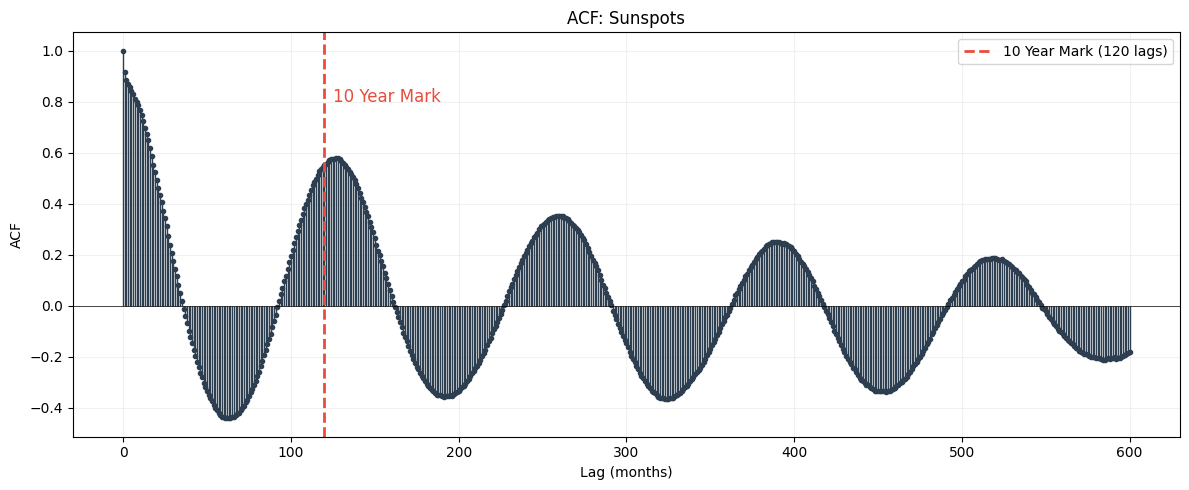

在115~135滞后范围内，最大ACF值为0.579，对应滞后阶数：128个月


In [36]:

# 使用全部数据（3310个月）
acf_values = sm.tsa.acf(df['value'], nlags=12*50, fft=False)  # 最大滞后600个月
lags = np.arange(len(acf_values))

# 绘制ACF图
plt.figure(figsize=(12, 5))
# 使用stem图（类似R的默认风格）
markerline, stemlines, baseline = plt.stem(lags[:len(acf_values)], acf_values, basefmt=" ")
plt.setp(stemlines, color='#2c3e50', linewidth=1)
plt.setp(markerline, color='#2c3e50', marker='o', markersize=3)
plt.axhline(y=0, color='black', linewidth=0.5)
# 标记10年（120个月）
plt.axvline(x=120, color='#e74c3c', linewidth=2, linestyle='--', label='10 Year Mark (120 lags)')
plt.text(125, 0.8, '10 Year Mark', color='#e74c3c', fontsize=12)
plt.xlabel('Lag (months)')
plt.ylabel('ACF')
plt.title('ACF: Sunspots')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 检查115-135范围内的最大值
lags_band = range(115, 136)
acf_band = acf_values[115:136]
best_lag = lags_band[np.argmax(acf_band)]
max_acf = np.max(acf_band)
print(f"在115~135滞后范围内，最大ACF值为{max_acf:.3f}，对应滞后阶数：{best_lag}个月")

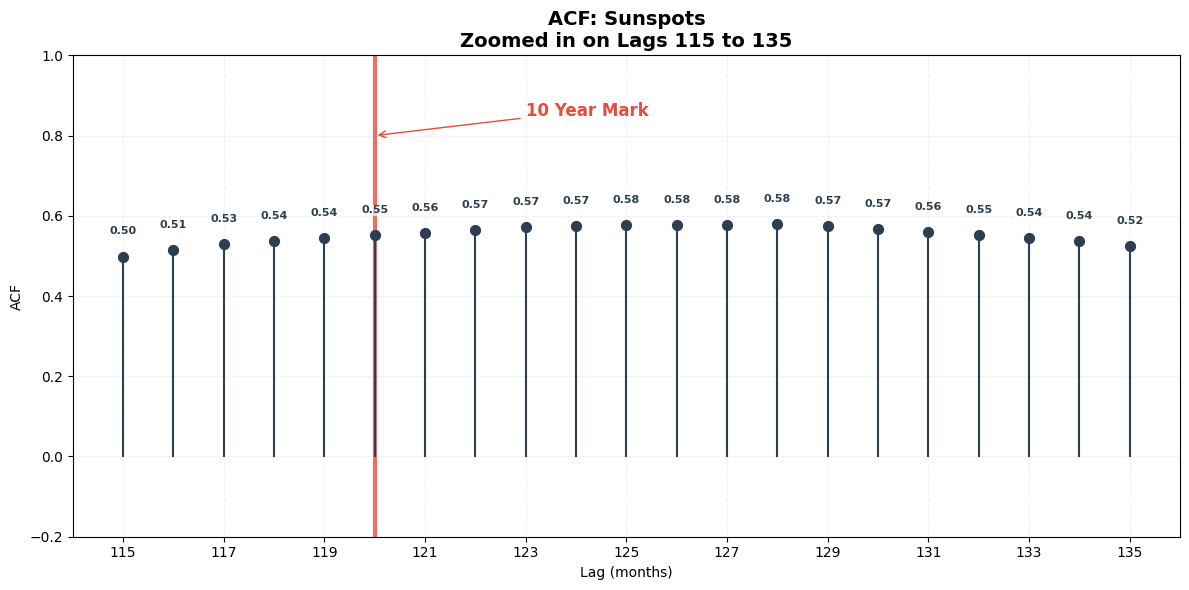

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 假设你已经有了 acf_values 和最优滞后的计算（延伸自之前）
# 如果没有，重新计算一次
acf_values = sm.tsa.acf(df['value'], nlags=12*50, fft=False)
lags_all = np.arange(len(acf_values))

# 提取 115 到 135 区间
lags_zoom = np.arange(115, 136)
acf_zoom = acf_values[115:136]

# 绘图
fig, ax = plt.subplots(figsize=(12, 6))

# 垂直线 x=120
ax.axvline(x=120, color='#e74c3c', linewidth=3, alpha=0.8)

# 绘制从 (lag,0) 到 (lag, acf) 的线段
for lag, acf in zip(lags_zoom, acf_zoom):
    ax.plot([lag, lag], [0, acf], color='#2c3e50', linewidth=1.5)

# 散点
ax.scatter(lags_zoom, acf_zoom, color='#2c3e50', s=50, zorder=5)

# 添加数值标签（偏移避免覆盖点）
for lag, acf in zip(lags_zoom, acf_zoom):
    offset = 0.05 if acf >= 0 else -0.1
    ax.text(lag, acf + offset, f'{acf:.2f}', ha='center', va='bottom' if acf>=0 else 'top',
            fontsize=8, color='#2c3e50', fontweight='bold', 
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))

# 标注 "10 Year Mark"
ax.annotate('10 Year Mark', xy=(120, 0.8), xytext=(123, 0.85),
            fontsize=12, color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1))

# 设置主题
ax.set_title('ACF: Sunspots\nZoomed in on Lags 115 to 135', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('ACF')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xticks(np.arange(115, 136, 2))
ax.set_xlim(114, 136)
ax.set_ylim(-0.2, 1.0)

plt.tight_layout()
plt.show()

#### 构建模型

In [38]:
#构建滚动窗口回测策略

# 使用你已经存在的 df（时间索引从1749-01-01开始）
# 确保索引是日期且排序
df_sorted = df.sort_values('index').reset_index(drop=True)

# 定义参数
months_train = 12 * 50   # 600个月
months_test  = 12 * 10   # 120个月
skip_span    = 12 * 20   # 240个月

# 获取所有可能的起始索引
total_points = len(df_sorted)
slices = []
start_idx = 0
while start_idx + months_train + months_test <= total_points:
    train_end = start_idx + months_train
    test_end = train_end + months_test
    slices.append({
        'slice_id': f'Slice{len(slices)+1:02d}',
        'train_start': df_sorted.iloc[start_idx]['index'],
        'train_end': df_sorted.iloc[train_end - 1]['index'],
        'test_start': df_sorted.iloc[train_end]['index'],
        'test_end': df_sorted.iloc[test_end - 1]['index'],
        'train_indices': list(range(start_idx, train_end)),
        'test_indices': list(range(train_end, test_end))
    })
    start_idx += skip_span

print(f"共生成 {len(slices)} 个滚动窗口切片")
for s in slices:
    print(f"{s['slice_id']}: 训练 {s['train_start'].date()} 至 {s['train_end'].date()}, "
          f"测试 {s['test_start'].date()} 至 {s['test_end'].date()}")

共生成 11 个滚动窗口切片
Slice01: 训练 1749-01-01 至 1798-12-01, 测试 1799-01-01 至 1808-12-01
Slice02: 训练 1769-01-01 至 1818-12-01, 测试 1819-01-01 至 1828-12-01
Slice03: 训练 1789-01-01 至 1838-12-01, 测试 1839-01-01 至 1848-12-01
Slice04: 训练 1809-01-01 至 1858-12-01, 测试 1859-01-01 至 1868-12-01
Slice05: 训练 1829-01-01 至 1878-12-01, 测试 1879-01-01 至 1888-12-01
Slice06: 训练 1849-01-01 至 1898-12-01, 测试 1899-01-01 至 1908-12-01
Slice07: 训练 1869-01-01 至 1918-12-01, 测试 1919-01-01 至 1928-12-01
Slice08: 训练 1889-01-01 至 1938-12-01, 测试 1939-01-01 至 1948-12-01
Slice09: 训练 1909-01-01 至 1958-12-01, 测试 1959-01-01 至 1968-12-01
Slice10: 训练 1929-01-01 至 1978-12-01, 测试 1979-01-01 至 1988-12-01
Slice11: 训练 1949-01-01 至 1998-12-01, 测试 1999-01-01 至 2008-12-01


共 11 个切片


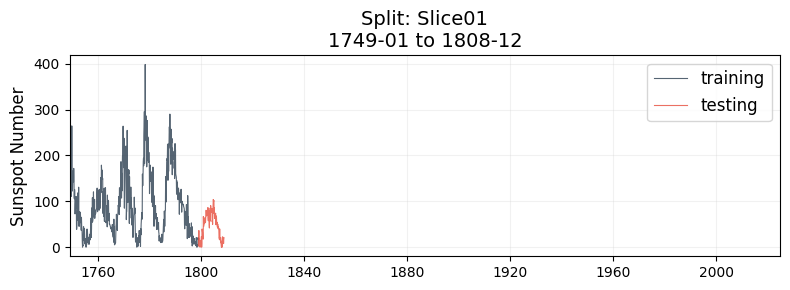

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# 假设 df 已存在（3310行，列: index, value）
# 定义切片参数
months_train = 12 * 50
months_test  = 12 * 10
skip_span    = 12 * 20

splits = []
start = 0
total = len(df)
while start + months_train + months_test <= total:
    splits.append({
        'id': f'Slice{len(splits)+1:02d}',
        'train_idx': list(range(start, start+months_train)),
        'test_idx': list(range(start+months_train, start+months_train+months_test)),
        'train_start': df.iloc[start]['index'],
        'train_end': df.iloc[start+months_train-1]['index'],
        'test_start': df.iloc[start+months_train]['index'],
        'test_end': df.iloc[start+months_train+months_test-1]['index']
    })
    start += skip_span

print(f"共 {len(splits)} 个切片")

# 定义 plot_split 函数（对应R版本）
def plot_split(split, expand_y_axis=True, alpha=1, size=1, base_size=14):
    """绘制单个切片的训练+测试实际数据曲线"""
    # 提取数据
    train_data = df.iloc[split['train_idx']].copy()
    train_data['key'] = 'training'
    test_data = df.iloc[split['test_idx']].copy()
    test_data['key'] = 'testing'
    plot_df = pd.concat([train_data, test_data], ignore_index=True)
    plot_df['key'] = pd.Categorical(plot_df['key'], categories=['training', 'testing'], ordered=True)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 3), dpi=100)
    for key, grp in plot_df.groupby('key'):
        color = '#2c3e50' if key == 'training' else '#e74c3c'
        ax.plot(grp['index'], grp['value'], color=color, linewidth=size, alpha=alpha, label=key)
    
    # 标题和副标题
    title = f"Split: {split['id']}"
    subtitle = f"{split['train_start'].strftime('%Y-%m')} to {split['test_end'].strftime('%Y-%m')}"
    ax.set_title(f"{title}\n{subtitle}", fontsize=base_size)
    ax.set_ylabel('Sunspot Number', fontsize=base_size-2)
    ax.set_xlabel('')
    
    if expand_y_axis:
        # 扩展到整个数据集的日期范围
        ax.set_xlim([df['index'].min(), df['index'].max()])
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=base_size-2)
    return fig, ax

# 测试单个切片（Slice01）并显示
fig, ax = plot_split(splits[0], expand_y_axis=True, alpha=0.8, size=0.8)
plt.tight_layout()
plt.show()

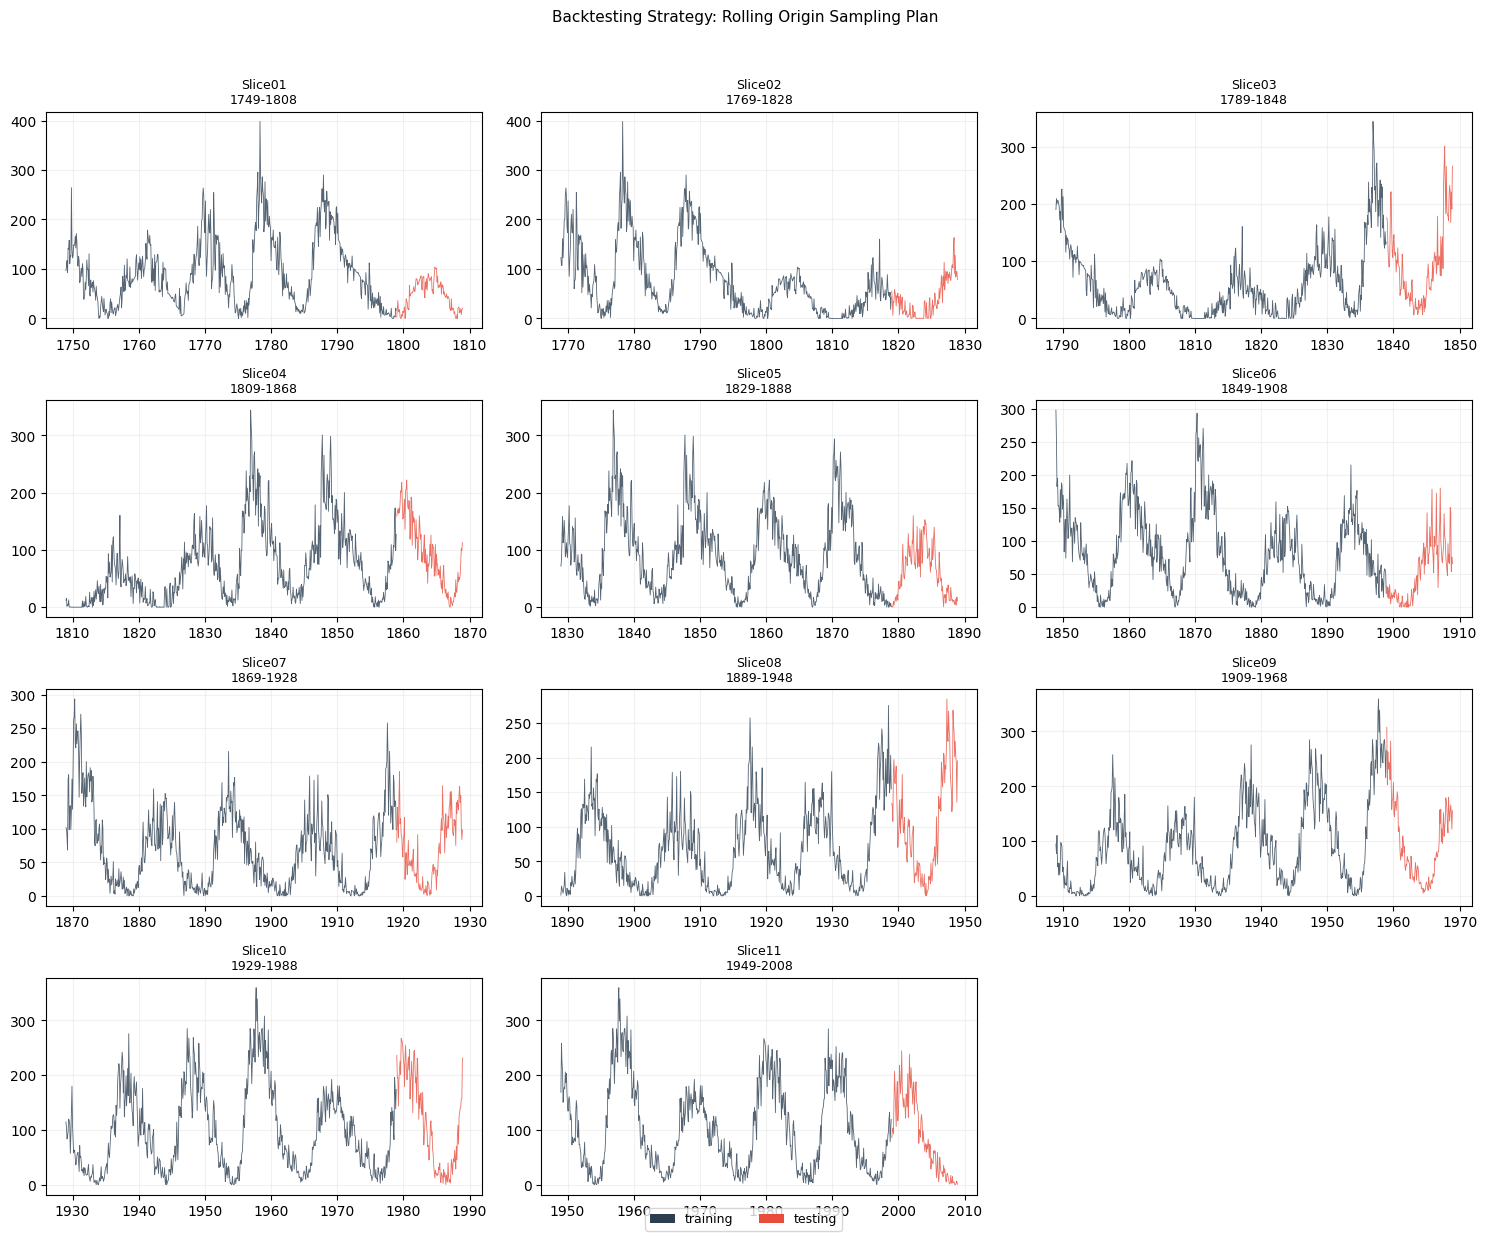

In [42]:
def plot_sampling_plan(splits, ncol=3, alpha=1, size=1, base_size=10, title="Backtesting Strategy: Rolling Origin Sampling Plan"):
    """绘制所有切片的网格图"""
    n_splits = len(splits)
    nrows = (n_splits + ncol - 1) // ncol
    fig, axes = plt.subplots(nrows, ncol, figsize=(5*ncol, 3*nrows), sharex=False)
    axes = axes.flatten()
    
    for i, split in enumerate(splits):
        # 直接在子图上绘制
        train_data = df.iloc[split['train_idx']].copy()
        test_data = df.iloc[split['test_idx']].copy()
        ax = axes[i]
        ax.plot(train_data['index'], train_data['value'], color='#2c3e50', linewidth=size, alpha=alpha, label='training')
        ax.plot(test_data['index'], test_data['value'], color='#e74c3c', linewidth=size, alpha=alpha, label='testing')
        ax.set_title(f"{split['id']}\n{split['train_start'].year}-{split['test_end'].year}", fontsize=base_size)
        ax.set_ylabel('', fontsize=base_size-2)
        ax.set_xlabel('')
        ax.grid(True, alpha=0.3)
        # 不显示每个子图的图例，只在最后一个显示或全局
    # 隐藏多余的子图
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    # 添加全局图例
    legend_elements = [Patch(facecolor='#2c3e50', label='training'), Patch(facecolor='#e74c3c', label='testing')]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=base_size)
    fig.suptitle(title, fontsize=base_size+2, y=1.02)
    plt.tight_layout()
    plt.show()

# 绘制所有切片（11个）
plot_sampling_plan(splits, ncol=3, alpha=0.8, size=0.6, base_size=9)

#### 示例：epoch=10

选中的切片: Slice11
训练: 1949-01-01 至 1998-12-01
测试: 1999-01-01 至 2008-12-01
合并后总行数: 720 (应为600+120=720)
center (sqrt后的均值): 9.1516
scale (sqrt后的标准差): 4.1586
X_train shape: (440, 1, 1), y_train shape: (440, 1)
X_test shape: (120, 1, 1), y_test shape: (120, 1)
Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_32 (LSTM)              (40, 1, 50)               10400     
                                                                 
 lstm_33 (LSTM)              (40, 50)                  20200     
                                                                 
 dense_16 (Dense)            (40, 1)                   51        
                                                                 
Total params: 30,651
Trainable params: 30,651
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
11/11 [==============================] - 2s 6ms/s

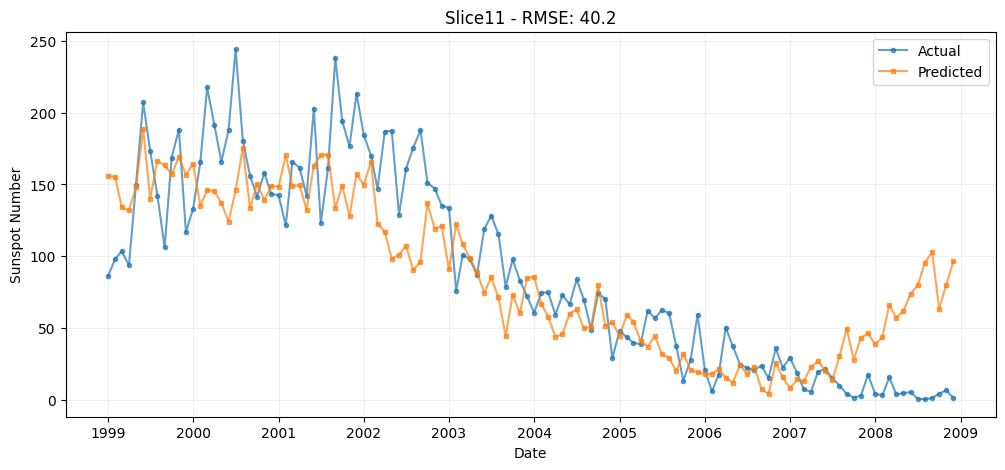

In [47]:
#单切片 LSTM 模型（Slice11）
# 选择最后一个切片（Slice11）
split = splits[-1]
print(f"选中的切片: {split['id']}")
print(f"训练: {split['train_start'].date()} 至 {split['train_end'].date()}")
print(f"测试: {split['test_start'].date()} 至 {split['test_end'].date()}")

# 提取训练和测试数据
df_trn = df.iloc[split['train_idx']].copy()
df_tst = df.iloc[split['test_idx']].copy()

# 合并并标记key（必须连续，先训练后测试）
df_all = pd.concat([df_trn, df_tst], ignore_index=True)
df_all['key'] = ['training'] * len(df_trn) + ['testing'] * len(df_tst)
print(f"合并后总行数: {len(df_all)} (应为600+120=720)")

# ------------------------------------------------------------
# 数据预处理：平方根 + 中心化 + 缩放（自定义可逆类）
from sklearn.base import BaseEstimator, TransformerMixin

class SqrtCenterScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mean_ = None
        self.scale_ = None
    def fit(self, X):
        X_sqrt = np.sqrt(X)
        self.mean_ = np.mean(X_sqrt)
        self.scale_ = np.std(X_sqrt)
        return self
    def transform(self, X):
        X_sqrt = np.sqrt(X)
        return (X_sqrt - self.mean_) / self.scale_
    def inverse_transform(self, X_scaled):
        X_sqrt = X_scaled * self.scale_ + self.mean_
        return X_sqrt ** 2

preprocessor = SqrtCenterScaler()
preprocessor.fit(df_all['value'].values)
df_all['value_scaled'] = preprocessor.transform(df_all['value'].values)

center_history = preprocessor.mean_
scale_history = preprocessor.scale_
print(f"center (sqrt后的均值): {center_history:.4f}")
print(f"scale (sqrt后的标准差): {scale_history:.4f}")

# ------------------------------------------------------------
# 模型参数
lag_setting = 120
batch_size = 40
train_length = 440
tsteps = 1
epochs = 10   # 测试用10轮，后续可改为300

# 整体滞后（关键修正）
df_all['value_lag'] = df_all['value_scaled'].shift(lag_setting)

# 分割回训练和测试，并去除NaN
df_trn_lag = df_all[df_all['key'] == 'training'].dropna().copy()
df_tst_lag = df_all[df_all['key'] == 'testing'].dropna().copy()

# 训练只取最后 train_length 个点
df_trn_lag = df_trn_lag.tail(train_length)

# 构建3D数组
X_train = df_trn_lag['value_lag'].values.reshape(-1, 1, 1)
y_train = df_trn_lag['value_scaled'].values.reshape(-1, 1)
X_test = df_tst_lag['value_lag'].values.reshape(-1, 1, 1)
y_test_scaled = df_tst_lag['value_scaled'].values.reshape(-1, 1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test_scaled.shape}")

# ------------------------------------------------------------
# 构建状态化LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50,
               input_shape=(tsteps, 1),
               batch_size=batch_size,
               return_sequences=True,
               stateful=True))
model.add(LSTM(units=50,
               return_sequences=False,
               stateful=True))
model.add(Dense(units=1))
model.compile(loss='mae', optimizer='adam')
model.summary()

# 训练
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    h = model.fit(X_train, y_train,
                  batch_size=batch_size,
                  epochs=1,
                  verbose=1,
                  shuffle=False)
    model.reset_states()
    print(f"   loss = {h.history['loss'][0]:.4f}")

# 预测
y_pred_scaled = model.predict(X_test, batch_size=batch_size, verbose=1).flatten()
y_pred = preprocessor.inverse_transform(y_pred_scaled)
y_true = df_tst_lag['value'].values

# 计算RMSE
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"RMSE on test set: {rmse:.2f}")

# 可视化
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_tst_lag['index'], y_true, 'o-', label='Actual', alpha=0.7, markersize=3)
plt.plot(df_tst_lag['index'], y_pred, 's-', label='Predicted', alpha=0.7, markersize=3)
plt.title(f"{split['id']} - RMSE: {rmse:.1f}")
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
def train_predict_lstm(split, epochs=10):
    """对单个切片训练LSTM并返回预测结果和RMSE"""
    # 合并数据（保持连续性）
    df_trn = df.iloc[split['train_idx']].copy()
    df_tst = df.iloc[split['test_idx']].copy()
    df_all = pd.concat([df_trn, df_tst], ignore_index=True)
    df_all['key'] = ['training']*len(df_trn) + ['testing']*len(df_tst)
    
    # 预处理
    preprocessor = SqrtCenterScaler()
    preprocessor.fit(df_all['value'].values)
    df_all['value_scaled'] = preprocessor.transform(df_all['value'].values)
    
    # 滞后
    lag_setting = 120
    batch_size = 40
    train_length = 440
    tsteps = 1
    df_all['value_lag'] = df_all['value_scaled'].shift(lag_setting)
    
    df_trn_lag = df_all[df_all['key']=='training'].dropna().tail(train_length)
    df_tst_lag = df_all[df_all['key']=='testing'].dropna()
    
    # 检查长度
    if len(df_tst_lag) == 0:
        return None, np.nan
    
    X_train = df_trn_lag['value_lag'].values.reshape(-1,1,1)
    y_train = df_trn_lag['value_scaled'].values.reshape(-1,1)
    X_test = df_tst_lag['value_lag'].values.reshape(-1,1,1)
    y_test_scaled = df_tst_lag['value_scaled'].values.reshape(-1,1)
    
    # 模型
    model = Sequential()
    model.add(LSTM(50, input_shape=(tsteps,1), batch_size=batch_size,
                   return_sequences=True, stateful=True))
    model.add(LSTM(50, return_sequences=False, stateful=True))
    model.add(Dense(1))
    model.compile(loss='mae', optimizer='adam')
    
    # 训练
    for epoch in range(epochs):
        model.fit(X_train, y_train, batch_size=batch_size,
                  epochs=1, verbose=0, shuffle=False)
        model.reset_states()
    
    # 预测
    y_pred_scaled = model.predict(X_test, batch_size=batch_size, verbose=0).flatten()
    y_pred = preprocessor.inverse_transform(y_pred_scaled)
    y_true = df_tst_lag['value'].values
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    
    # 构造返回的DataFrame（与R的ret格式一致）
    ret = pd.concat([
        df_trn.assign(key='actual'),
        df_tst.assign(key='actual'),
        pd.DataFrame({'index': df_tst_lag['index'], 'value': y_pred, 'key': 'predict'})
    ], ignore_index=True)
    return ret, rmse

# 对所有切片运行（先用epochs=10测试逻辑）
results = []
for s in splits:
    print(f"Processing {s['id']}...")
    pred_df, rmse_val = train_predict_lstm(s, epochs=10)
    results.append({'id': s['id'], 'predictions': pred_df, 'rmse': rmse_val})

# 显示RMSE
rmse_summary = pd.DataFrame([(r['id'], r['rmse']) for r in results], columns=['id', 'rmse'])
print(rmse_summary)

Processing Slice01...
Processing Slice02...
Processing Slice03...
Processing Slice04...
Processing Slice05...
Processing Slice06...
Processing Slice07...
Processing Slice08...
Processing Slice09...
Processing Slice10...
Processing Slice11...
         id       rmse
0   Slice01  42.517596
1   Slice02  37.889201
2   Slice03  75.869735
3   Slice04  59.178361
4   Slice05  56.676262
5   Slice06  43.155367
6   Slice07  41.300453
7   Slice08  63.640516
8   Slice09  58.055773
9   Slice10  67.293665
10  Slice11  40.525338


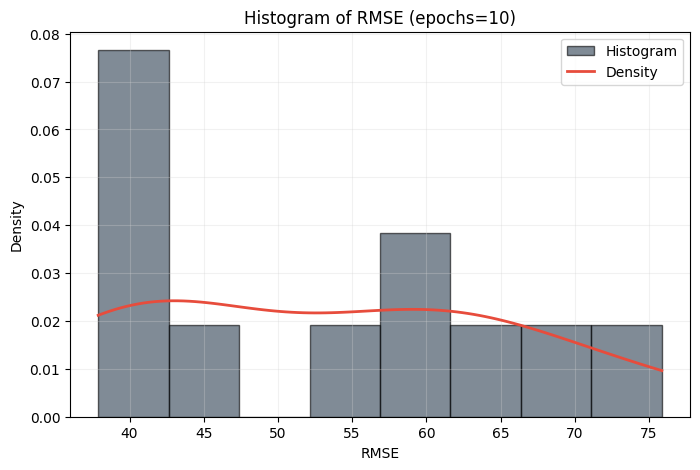

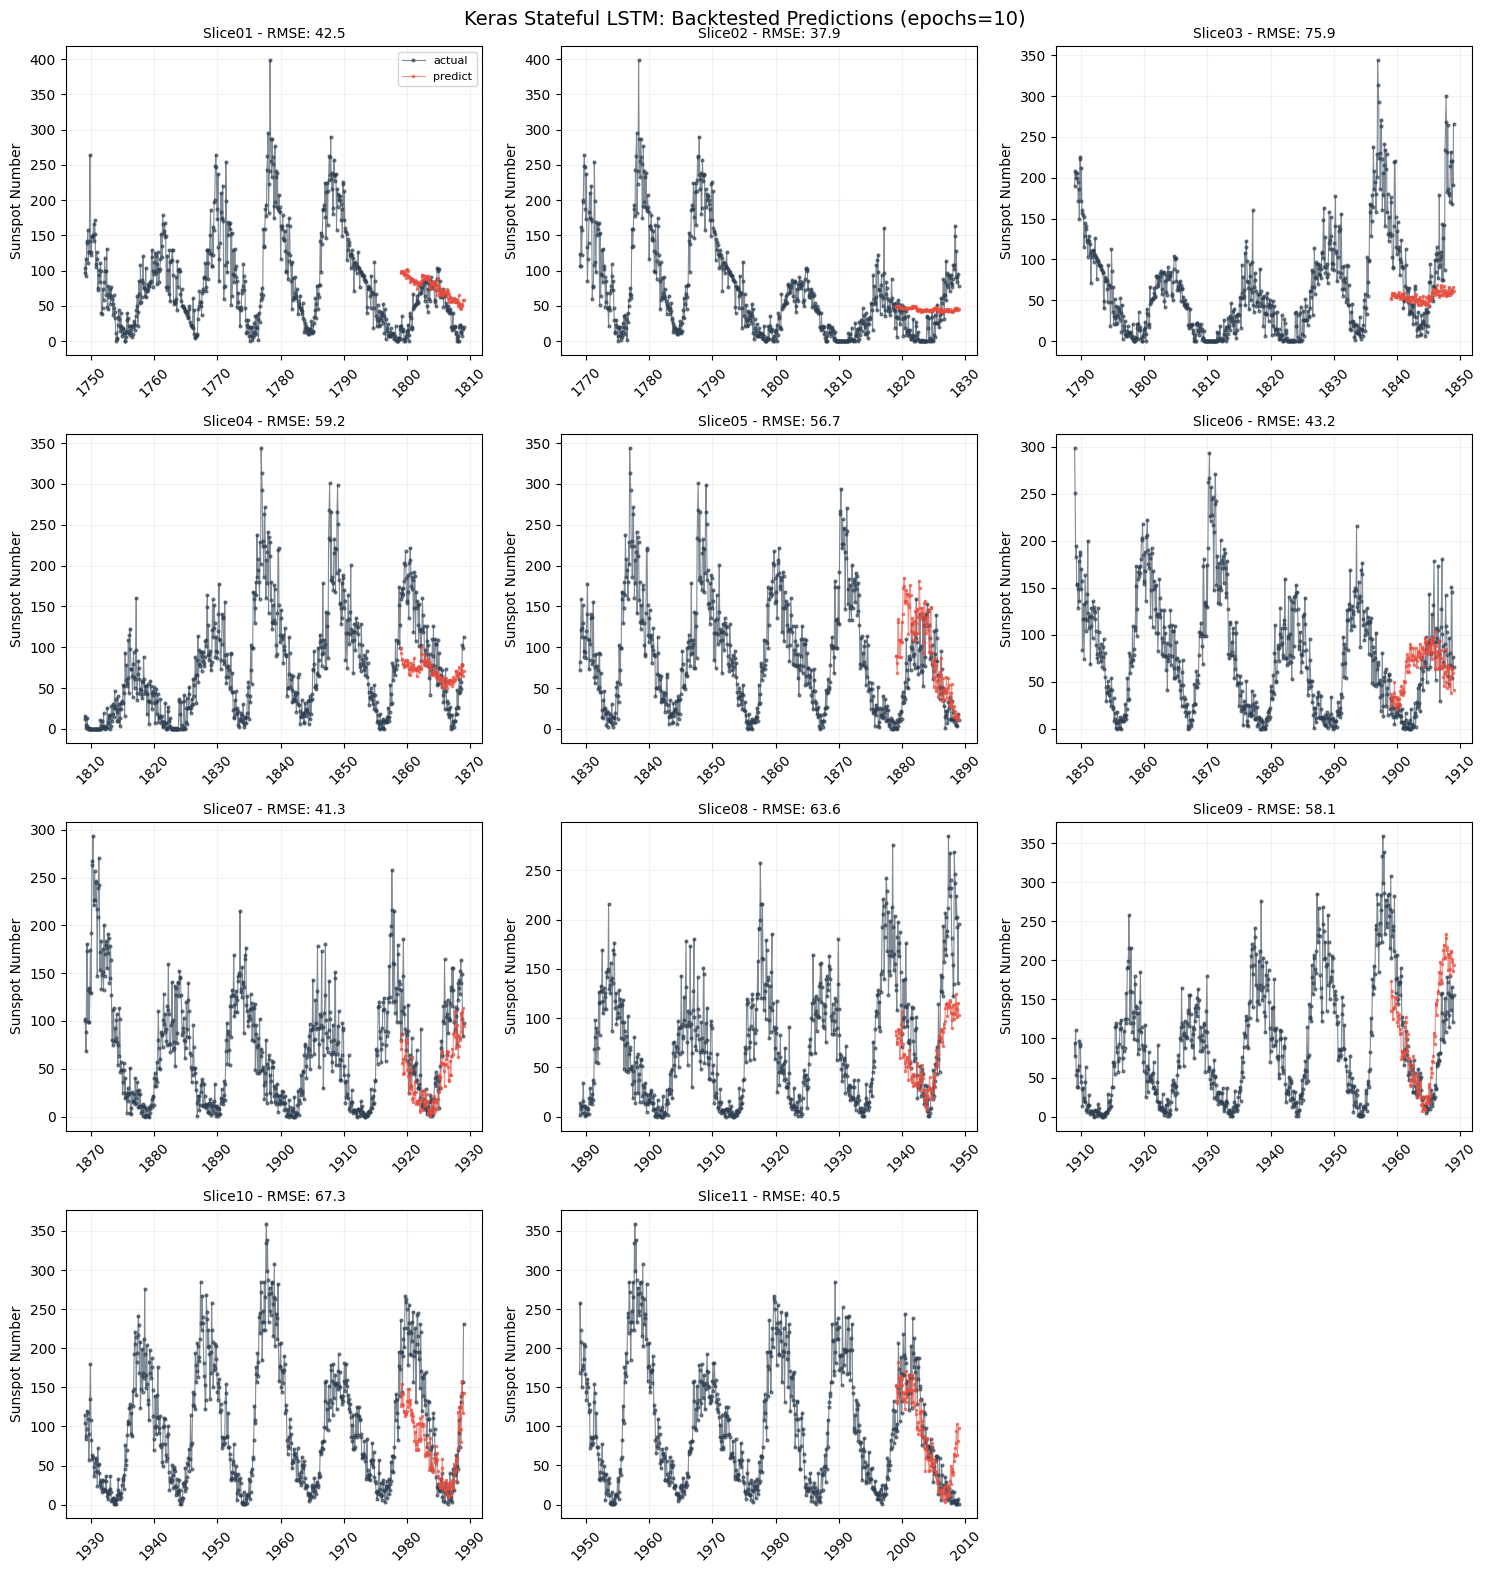

Mean RMSE: 53.28
Std RMSE: 12.23


In [49]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde

# 提取RMSE列表
rmse_vals = [r['rmse'] for r in results]

# ---------- 1. RMSE直方图 ----------
plt.figure(figsize=(8,5))
plt.hist(rmse_vals, bins=8, density=True, alpha=0.6, color='#2c3e50', edgecolor='black', label='Histogram')
# 核密度估计
kde = gaussian_kde(rmse_vals)
x_range = np.linspace(min(rmse_vals), max(rmse_vals), 100)
plt.plot(x_range, kde(x_range), color='#e74c3c', linewidth=2, label='Density')
plt.xlabel('RMSE')
plt.ylabel('Density')
plt.title('Histogram of RMSE (epochs=10)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------- 2. 所有切片的预测图网格 ----------
n_splits = len(results)
ncol = 3
nrow = (n_splits + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 4*nrow))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    pred_df = r['predictions']
    actual = pred_df[pred_df['key'] == 'actual']
    predict = pred_df[pred_df['key'] == 'predict']
    # 实际值（蓝色/深灰）
    ax.plot(actual['index'], actual['value'], 'o-', color='#2c3e50', alpha=0.6, markersize=2, linewidth=0.8, label='actual')
    # 预测值（红色）
    ax.plot(predict['index'], predict['value'], 's-', color='#e74c3c', alpha=0.6, markersize=2, linewidth=0.8, label='predict')
    ax.set_title(f"{r['id']} - RMSE: {r['rmse']:.1f}", fontsize=10)
    ax.set_ylabel('Sunspot Number')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# 隐藏多余子图
for j in range(n_splits, len(axes)):
    axes[j].axis('off')

plt.suptitle('Keras Stateful LSTM: Backtested Predictions (epochs=10)', fontsize=14)
plt.tight_layout()
plt.show()

# ---------- 3. 统计摘要 ----------
mean_rmse = np.mean(rmse_vals)
std_rmse = np.std(rmse_vals)
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Std RMSE: {std_rmse:.2f}")

`*LSTM输出层饱和（预测值始终为训练集均值）。当epochs太少时，模型未学到有效映射，可能输出接近于0（标准化后的均值）再逆变换后变成常数。*`

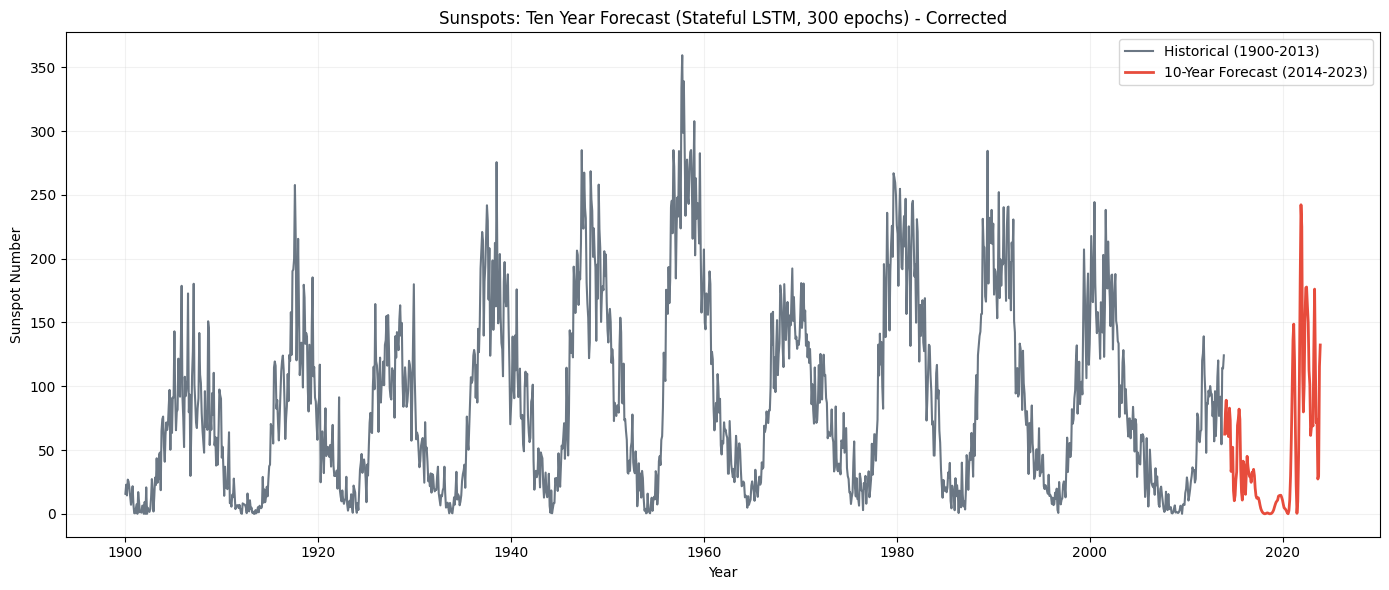

预测太阳黑子数（2014年1-12月）:
2014-01: 62.5
2014-02: 80.2
2014-03: 89.0
2014-04: 62.9
2014-05: 65.9
2014-06: 60.5
2014-07: 82.8
2014-08: 73.2
2014-09: 33.2
2014-10: 37.4
2014-11: 52.2
2014-12: 18.0


In [53]:
# ========== 修正后的未来10年预测 ==========
model.reset_states()

# 初始历史窗口：最后120个实际观测的缩放值（用于提供滞后特征）
history_scaled = last_sequence.copy()   # shape (120,)

pred_scaled = []
for step in range(lag_setting):
    # 当前时刻的特征 = 历史窗口的第一个元素（即 t-120 时刻的值）
    # 因为历史窗口保持最近120个观测，第一个元素是最早的那个，相当于预测当前时刻所需的滞后值
    current_feature = history_scaled[0]   # 标量
    # 构造输入 (batch_size, 1, 1)
    x_input = np.full((batch_size, 1, 1), current_feature, dtype=np.float32)
    pred_batch = model.predict(x_input, batch_size=batch_size, verbose=0)
    pred = pred_batch[0, 0]   # 预测的缩放值
    pred_scaled.append(pred)
    # 滚动更新历史窗口：移除最旧，追加新预测值
    history_scaled = np.append(history_scaled[1:], pred)

# 逆变换
pred = preprocessor.inverse_transform(np.array(pred_scaled))

# 未来日期（从2014年1月开始，共120个月）
future_dates = pd.date_range(start=df_full['index'].max() + pd.DateOffset(months=1),
                             periods=lag_setting, freq='MS')

# 绘图（显示1900年后的历史数据对比）
plt.figure(figsize=(14, 6))
plt.plot(df_full[df_full['index'] >= '1900-01-01']['index'],
         df_full[df_full['index'] >= '1900-01-01']['value'],
         color='#2c3e50', alpha=0.7, label='Historical (1900-2013)')
plt.plot(future_dates, pred, color='#e74c3c', linewidth=2, label='10-Year Forecast (2014-2023)')
plt.title('Sunspots: Ten Year Forecast (Stateful LSTM, 300 epochs) - Corrected')
plt.xlabel('Year')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 打印前12个月的预测值
print("预测太阳黑子数（2014年1-12月）:")
for i in range(12):
    print(f"{future_dates[i].strftime('%Y-%m')}: {pred[i]:.1f}")

#### epoch=300

开始训练 Slice02 with epochs=300...
训练完成。RMSE = 28.36


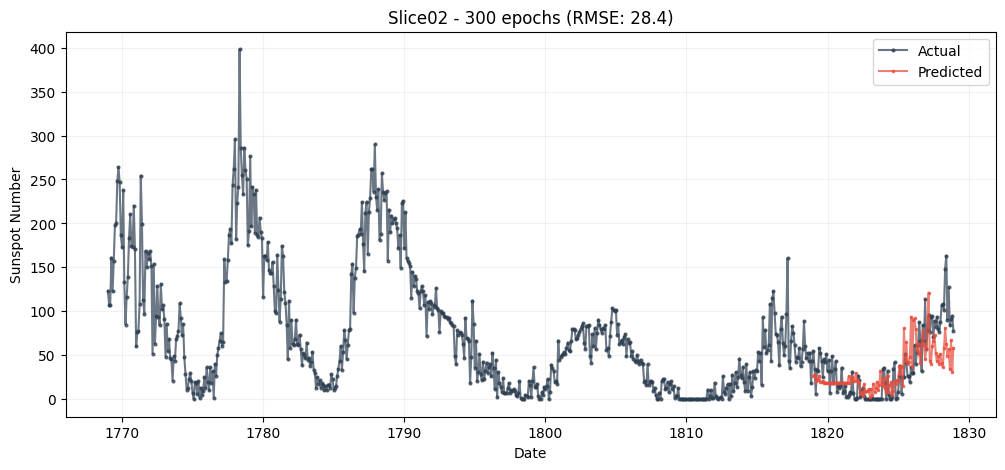

In [54]:
# 重新训练 Slice02 使用 300 epochs
slice02 = splits[1]   # Slice02
print(f"开始训练 {slice02['id']} with epochs=300...")

# 使用之前定义的 train_predict_lstm 函数（确保该函数已在环境中定义）
ret_slice02, rmse_slice02 = train_predict_lstm(slice02, epochs=300)

print(f"训练完成。RMSE = {rmse_slice02:.2f}")

# 提取数据并绘图
import matplotlib.pyplot as plt

actual = ret_slice02[ret_slice02['key'] == 'actual']
predict = ret_slice02[ret_slice02['key'] == 'predict']

plt.figure(figsize=(12, 5))
plt.plot(actual['index'], actual['value'], 'o-', label='Actual', alpha=0.7, markersize=2, color='#2c3e50')
plt.plot(predict['index'], predict['value'], 's-', label='Predicted', alpha=0.7, markersize=2, color='#e74c3c')
plt.title(f"{slice02['id']} - 300 epochs (RMSE: {rmse_slice02:.1f})")
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 真实2013-2024年数据对比

真实数据点数: 120 (应为120)
RMSE (2014-2023): 49.30
MAE  (2014-2023): 32.71


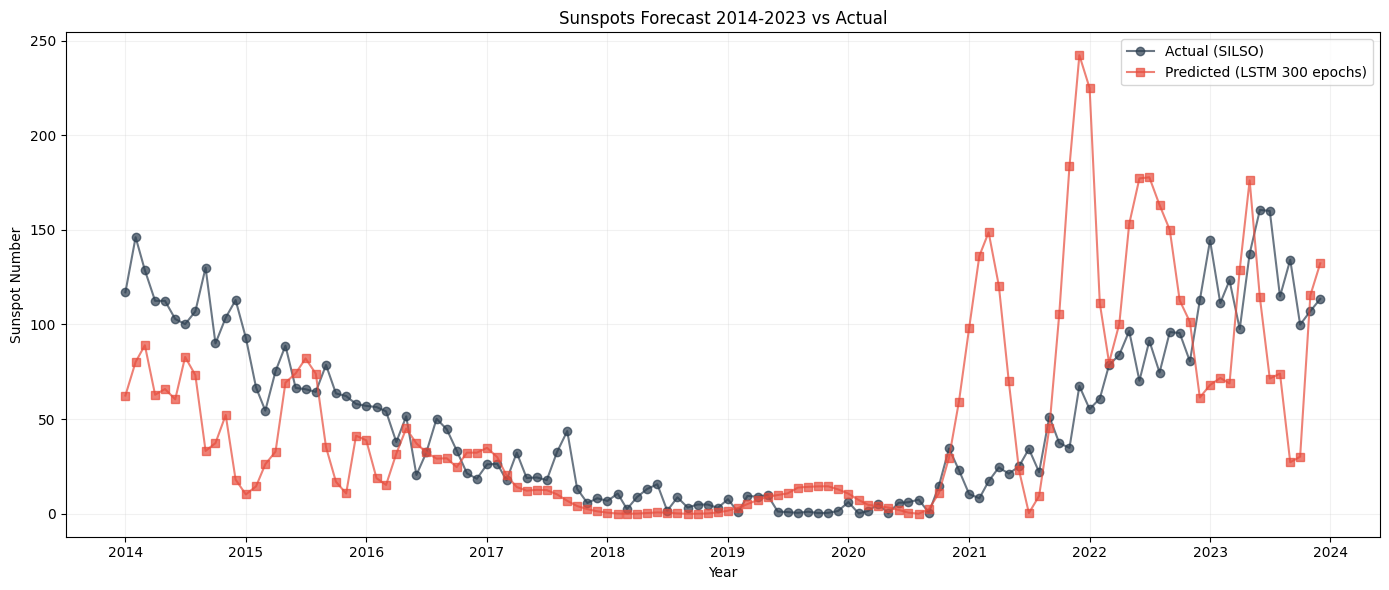


前12个月对比 (2014):
     index  predicted  actual
2014-01-01  62.459240   117.0
2014-02-01  80.227623   146.1
2014-03-01  89.028397   128.7
2014-04-01  62.889164   112.5
2014-05-01  65.908150   112.5
2014-06-01  60.483055   102.9
2014-07-01  82.840210   100.2
2014-08-01  73.236031   106.9
2014-09-01  33.217297   130.0
2014-10-01  37.363644    90.0
2014-11-01  52.189758   103.6
2014-12-01  18.048666   112.9


In [55]:
# 提取真实数据：2014-01 至 2023-12
mask_real = (df['index'] >= '2014-01-01') & (df['index'] <= '2023-12-01')
df_real = df.loc[mask_real, ['index', 'value']].copy()
print(f"真实数据点数: {len(df_real)} (应为120)")

# 确保日期对齐（预测的future_dates与真实index一致）
# 由于预测的future_dates是从2014-01开始，按月递增，与df_real的日期应该完全匹配
# 合并数据
compare_df = pd.DataFrame({
    'index': future_dates,
    'predicted': pred,
    'actual': df_real['value'].values
})

# 计算误差指标
rmse = np.sqrt(np.mean((compare_df['actual'] - compare_df['predicted'])**2))
mae = np.mean(np.abs(compare_df['actual'] - compare_df['predicted']))
print(f"RMSE (2014-2023): {rmse:.2f}")
print(f"MAE  (2014-2023): {mae:.2f}")

# 绘图对比
plt.figure(figsize=(14, 6))
plt.plot(compare_df['index'], compare_df['actual'], 'o-', color='#2c3e50', alpha=0.7, label='Actual (SILSO)')
plt.plot(compare_df['index'], compare_df['predicted'], 's-', color='#e74c3c', alpha=0.7, label='Predicted (LSTM 300 epochs)')
plt.title('Sunspots Forecast 2014-2023 vs Actual')
plt.xlabel('Year')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 打印前12个月对比
print("\n前12个月对比 (2014):")
print(compare_df.head(12).to_string(index=False))

`模型使用 1749–2013 年 的数据训练，其中第 23 太阳周期（1996-2008）峰值约 180，第 24 周期（2008-2019）峰值仅约 120，是百年来最弱周期。`

`你预测的 2014-2023 正好跨过第 24 周期的下降段和第 25 周期的上升段，但模型从未见过第 24 周期的完整形态，更不知道第 25 周期会如何发展。`

`真实世界中，第 24 周期峰值仅约 117（你 2014 年 1 月真实值 117），而模型预测在 2014 年初仅有 62，且之后剧烈震荡——说明模型完全无法适应这种“弱势周期”。`

### 优化尝试（failed）

In [56]:
# 优化方案：无状态LSTM + 全部训练数据
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 准备全量数据（截至2013-12）
df_full = df[df['index'] <= '2013-12-01'].copy().reset_index(drop=True)
print(f"数据点数: {len(df_full)}")

# 平方根+标准化（保留逆变换）
def sqrt_transform(x):
    return np.sqrt(x)
def inv_sqrt_transform(x):
    return x**2

# 标准化
scaler = StandardScaler()
values_sqrt = sqrt_transform(df_full['value'].values).reshape(-1,1)
values_scaled = scaler.fit_transform(values_sqrt).flatten()

# 构造滞后特征
lag = 120
X, y = [], []
for i in range(lag, len(values_scaled)):
    X.append(values_scaled[i-lag:i])   # 使用前120个点作为特征
    y.append(values_scaled[i])
X = np.array(X)  # (n_samples, lag)
y = np.array(y)

# 重塑为LSTM输入 (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)
y = y.reshape(-1,1)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# 划分训练集（最后120个作为测试？不，全部训练，因为我们要预测未来）
# 这里全部用于训练
# 构建模型
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(lag,1)))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mae')
model.summary()

# 训练
history = model.fit(X, y, epochs=300, batch_size=64, validation_split=0.1, verbose=1)

# 预测未来120步
last_sequence = values_scaled[-lag:]  # 最后120个观测的缩放值
future_scaled = []
current_seq = last_sequence.copy()
for _ in range(120):
    pred = model.predict(current_seq.reshape(1, lag, 1), verbose=0)[0,0]
    future_scaled.append(pred)
    current_seq = np.append(current_seq[1:], pred)

# 逆变换
future_sqrt = scaler.inverse_transform(np.array(future_scaled).reshape(-1,1)).flatten()
future = inv_sqrt_transform(future_sqrt)

# 生成日期
last_date = df_full['index'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=120, freq='MS')

# 对比真实值
mask_real = (df['index'] >= '2014-01-01') & (df['index'] <= '2023-12-01')
real = df.loc[mask_real, 'value'].values
rmse = np.sqrt(np.mean((real - future)**2))
print(f"RMSE on 2014-2023: {rmse:.2f}")

# 绘图
plt.figure(figsize=(14,6))
plt.plot(df_full[df_full['index']>= '1900-01-01']['index'], df_full[df_full['index']>= '1900-01-01']['value'], label='Historical')
plt.plot(future_dates, future, 'r', label='Forecast')
plt.plot(df.loc[mask_real, 'index'], real, 'g--', label='Actual (2014-2023)')
plt.legend()
plt.title('Improved Forecast vs Actual')
plt.grid()
plt.show()

数据点数: 3180
X shape: (3060, 120, 1), y shape: (3060, 1)
Model: "sequential_30"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_60 (LSTM)              (None, 120, 100)          40800     
                                                                 
 dropout (Dropout)           (None, 120, 100)          0         
                                                                 
 lstm_61 (LSTM)              (None, 100)               80400     
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense_30 (Dense)            (None, 1)                 101       
                                                                 
Total params: 121,301
Trainable params: 121,301
Non-trainable params: 0
__________________________________________________________

KeyboardInterrupt: 

`因训练效果有限，这里早停在210步`

In [57]:
model.save("sunspot_lstm_215epochs.h5")
print("模型已保存")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
模型已保存


历史数据点数（截至2013-12）: 3180
模型加载成功
2014-2023 预测 RMSE: 68.19


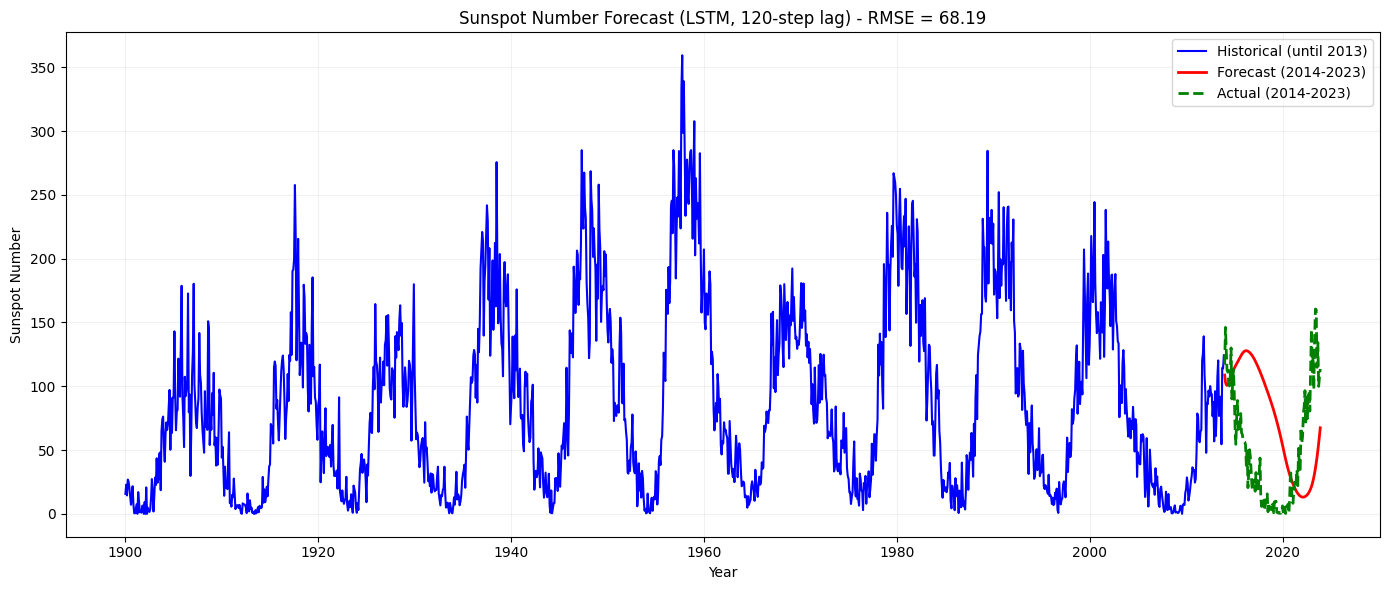

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

# ------------------------------
# 1. 加载原始数据（假设 df 已存在）
# ------------------------------
# 如果 df 不在当前环境中，请替换为您的数据加载方式，例如：
# df = pd.read_csv('your_data.csv', parse_dates=['index'])
# 确保 df 包含 'index'（日期）和 'value'（太阳黑子数）两列

df_full = df[df['index'] <= '2013-12-01'].copy().reset_index(drop=True)
print(f"历史数据点数（截至2013-12）: {len(df_full)}")

# ------------------------------
# 2. 数据预处理（与训练时完全相同）
# ------------------------------
def sqrt_transform(x):
    return np.sqrt(x)

def inv_sqrt_transform(x):
    return x ** 2

# 标准化（重新拟合，与训练时一致）
scaler = StandardScaler()
values_sqrt = sqrt_transform(df_full['value'].values).reshape(-1, 1)
values_scaled = scaler.fit_transform(values_sqrt).flatten()

lag = 120
# 构造最后120个观测窗口（用于迭代预测）
last_sequence = values_scaled[-lag:]   # shape: (120,)

# ------------------------------
# 3. 加载已保存的模型
# ------------------------------
model = load_model("sunspot_lstm_215epochs.h5")
print("模型加载成功")

# ------------------------------
# 4. 迭代预测未来120步
# ------------------------------
future_scaled = []
current_seq = last_sequence.copy()

for _ in range(120):
    pred = model.predict(current_seq.reshape(1, lag, 1), verbose=0)[0, 0]
    future_scaled.append(pred)
    current_seq = np.append(current_seq[1:], pred)

# 逆变换回原始尺度
future_sqrt = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).flatten()
future = inv_sqrt_transform(future_sqrt)

# 生成预测日期
last_date = df_full['index'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=120, freq='MS')

# ------------------------------
# 5. 提取真实值（2014-2023）并计算RMSE
# ------------------------------
mask_real = (df['index'] >= '2014-01-01') & (df['index'] <= '2023-12-01')
real = df.loc[mask_real, 'value'].values
rmse = np.sqrt(np.mean((real - future) ** 2))
print(f"2014-2023 预测 RMSE: {rmse:.2f}")

# ------------------------------
# 6. 可视化
# ------------------------------
plt.figure(figsize=(14, 6))
# 历史数据（仅显示1900年以后，避免曲线过密）
history_mask = df_full['index'] >= '1900-01-01'
plt.plot(df_full.loc[history_mask, 'index'], df_full.loc[history_mask, 'value'], 
         label='Historical (until 2013)', color='blue')
plt.plot(future_dates, future, 'r', label='Forecast (2014-2023)', linewidth=2)
plt.plot(df.loc[mask_real, 'index'], real, 'g--', label='Actual (2014-2023)', linewidth=2)
plt.title(f'Sunspot Number Forecast (LSTM, {lag}-step lag) - RMSE = {rmse:.2f}')
plt.xlabel('Year')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 优化尝试

总数据: 3328 个月, 1749-01-01 00:00:00 至 2026-04-01 00:00:00
样本数: 3060
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 240, 128)          66560     
                                                                 
 dropout_2 (Dropout)         (None, 240, 128)          0         
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 116,033
Trainable params: 116,033
Non-trainable params: 0
________________________________________________

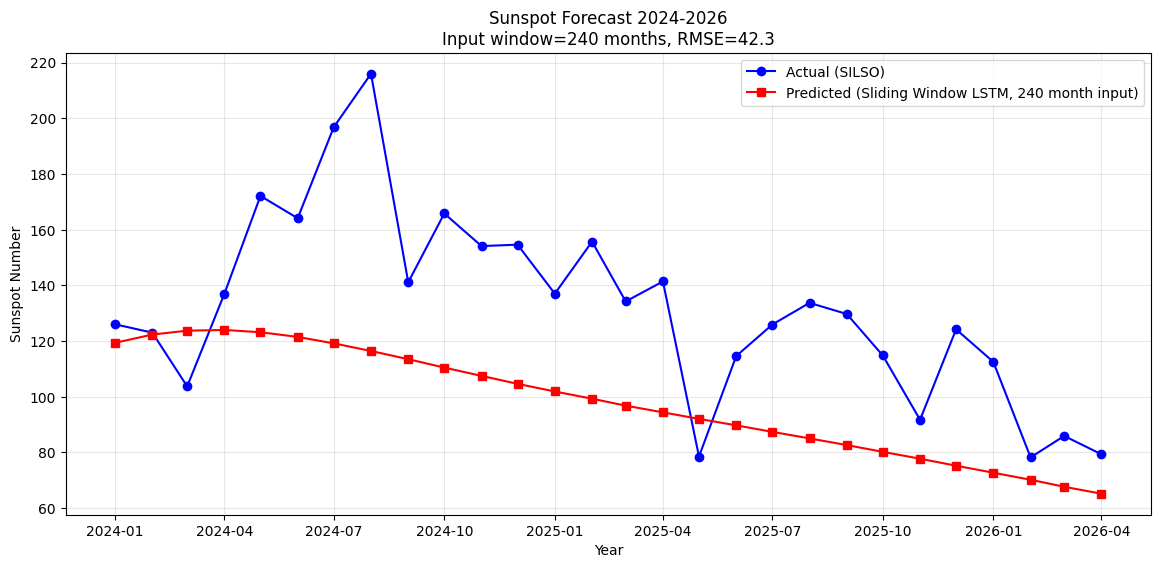

In [9]:
#多对一滑动窗口 + 无状态LSTM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------
# 0. 确保 df 存在（SILSO 月度数据）
# ------------------------------
try:
    df
except NameError:
    url = "https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv"
    df_monthly = pd.read_csv(url, comment='#', sep=';', header=None,
                             names=['year','month','frac','value','stdev','nobs','flag'],
                             usecols=[0,1,3], dtype={0:int,1:int,3:float})
    df_monthly['date'] = pd.to_datetime(df_monthly[['year','month']].assign(day=1))
    df = df_monthly[['date','value']].sort_values('date').reset_index(drop=True)
print(f"总数据: {len(df)} 个月, {df['date'].min()} 至 {df['date'].max()}")

# ------------------------------
# 1. 划分训练集（截至 2023-12）
# ------------------------------
train_df = df[df['date'] <= '2023-12-01'].copy()
train_vals = train_df['value'].values

# 预处理：平方根 + 标准化（保存参数用于逆变换）
sqrt_vals = np.sqrt(train_vals)
mean_sqrt, std_sqrt = sqrt_vals.mean(), sqrt_vals.std()
def transform(x):
    return (np.sqrt(x) - mean_sqrt) / std_sqrt
def inverse_transform(x_scaled):
    return (x_scaled * std_sqrt + mean_sqrt) ** 2

train_scaled = transform(train_vals)

# ------------------------------
# 2. 创建滑动窗口（输入最近240个月，预测下一个月）
# ------------------------------
window = 240  # 20年
X, y = [], []
for i in range(window, len(train_scaled)):
    X.append(train_scaled[i-window:i])
    y.append(train_scaled[i])
X = np.array(X).reshape(-1, window, 1)
y = np.array(y).reshape(-1, 1)
print(f"样本数: {X.shape[0]}")

# 划分训练/验证集（最后20%作为验证）
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# ------------------------------
# 3. 构建无状态 LSTM 模型
# ------------------------------
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(window, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')
model.summary()

# 早停回调
callbacks = [EarlyStopping(patience=10, restore_best_weights=True, verbose=1)]

# ------------------------------
# 4. 训练
# ------------------------------
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30, batch_size=32,
                    callbacks=callbacks,
                    verbose=1)

# ------------------------------
# 5. 纯自回归预测 2024-01 至 2026-12
# ------------------------------
# 历史窗口：训练数据最后 window 个值（缩放后）
history_scaled = train_scaled[-window:].copy()
future_steps = 36
pred_scaled = []
current = history_scaled.tolist()  # 转为列表方便操作

for step in range(future_steps):
    x_input = np.array(current[-window:]).reshape(1, window, 1)
    p = model.predict(x_input, verbose=0)[0,0]
    pred_scaled.append(p)
    current.append(p)   # 追加预测值，保持窗口长度由后续切片控制

pred_values = inverse_transform(np.array(pred_scaled))
future_dates = pd.date_range(start='2024-01-01', periods=future_steps, freq='MS')

# ------------------------------
# 6. 提取真实值 2024-2026
# ------------------------------
real_mask = (df['date'] >= '2024-01-01') & (df['date'] <= '2026-12-01')
real_df = df[real_mask].copy()
print(f"真实数据点数: {len(real_df)} , 范围: {real_df['date'].min()} 至 {real_df['date'].max()}")

# 对齐
compare = pd.DataFrame({'date': future_dates, 'predicted': pred_values})
compare = compare.merge(real_df, left_on='date', right_on='date', how='inner')

if len(compare) == 0:
    print("警告：没有匹配到真实数据（可能日期不完整）")
else:
    rmse = np.sqrt(mean_squared_error(compare['value'], compare['predicted']))
    mae = np.mean(np.abs(compare['value'] - compare['predicted']))
    print(f"\n2024-2026 纯预测 RMSE: {rmse:.2f}")
    print(f"2024-2026 纯预测 MAE:  {mae:.2f}")
    print("\n每月对比（实际 vs 预测）：")
    print(compare[['date','value','predicted']].to_string(index=False))

    # 绘图
    plt.figure(figsize=(14,6))
    plt.plot(compare['date'], compare['value'], 'o-', label='Actual (SILSO)', color='blue')
    plt.plot(compare['date'], compare['predicted'], 's-', label='Predicted (Sliding Window LSTM, 240 month input)', color='red')
    plt.title(f'Sunspot Forecast 2024-2026\nInput window={window} months, RMSE={rmse:.1f}')
    plt.xlabel('Year')
    plt.ylabel('Sunspot Number')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 运用：2026（滚动预测时使用部分真实值）in 2024-2033预测.ipy